# Experiment 4bc v2 — 강화 실험

| 실험 | 변경 사항 |
|------|---------|
| **4b** Active Learning | Random 5시드 평균 + GCN-Uncertainty + PC-GNN (WWW 2021) 베이스라인 추가 |
| **4c** Anomaly Detection | OCSVM + Autoencoder 베이스라인 추가, AISO 5시드 평균 |


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, copy, warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE   = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'
SEED   = 42

feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1,167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1,167)]
X_all   = labeled[feat_cols].values.astype(float)
y_all   = labeled['y'].values
ts_all  = labeled['timestep'].values
N_NODES = len(labeled)
X_scaled = StandardScaler().fit_transform(X_all)

txid_map = {tid: i for i, tid in enumerate(labeled['txId'].values)}
src_list, dst_list = [], []
for _, row in edge_df.iterrows():
    s, d = txid_map.get(row['txId1']), txid_map.get(row['txId2'])
    if s is not None and d is not None:
        src_list.append(s); dst_list.append(d)
src_arr = np.array(src_list); dst_arr = np.array(dst_list)

train_mask        = ts_all <= 34; test_mask = ts_all > 34
train_illicit_idx = np.where(train_mask & (y_all==1))[0]
train_licit_idx   = np.where(train_mask & (y_all==0))[0]
test_idx          = np.where(test_mask)[0]
sel_n = np.random.RandomState(SEED).choice(train_licit_idx, 10000, replace=False)

# Dom-12
src_bi = np.concatenate([src_arr,dst_arr]); dst_bi = np.concatenate([dst_arr,src_arr])
node_degree = np.bincount(src_bi, minlength=N_NODES).astype(float)
illicit_lbl = y_all.astype(float)
ill_ns = np.zeros(N_NODES); np.add.at(ill_ns, src_bi, illicit_lbl[dst_bi])
illicit_neigh_ratio = ill_ns / np.maximum(node_degree,1)
n2i = np.zeros(N_NODES); np.add.at(n2i, src_bi, illicit_neigh_ratio[dst_bi])
neigh2_illicit = n2i / np.maximum(node_degree,1)
hub_fraud = node_degree * illicit_neigh_ratio
ts_rate = {t: y_all[ts_all==t].mean() for t in np.unique(ts_all)}
node_ts_rate = np.array([ts_rate[t] for t in ts_all])
ts_norm = (ts_all-ts_all.min()) / max(ts_all.max()-ts_all.min(),1)
lf = X_scaled[:,1:94]; af = X_scaled[:,94:166]
domain_norm_12 = MMS().fit_transform(np.stack([
    node_degree, illicit_neigh_ratio, neigh2_illicit, node_ts_rate,
    lf.mean(1), lf.std(1), lf.max(1), af.mean(1), af.std(1), af.max(1),
    ts_norm, hub_fraud], axis=1))

print(f"N_NODES={N_NODES}  illicit={len(train_illicit_idx)}  licit={len(train_licit_idx)}")
print(f"sel_n={len(sel_n)}  test={len(test_idx)} (illicit={y_all[test_idx].sum()})")
print(f"Dom-12: {domain_norm_12.shape}")


c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


N_NODES=46564  illicit=3462  licit=26432
sel_n=10000  test=16670 (illicit=1083)
Dom-12: (46564, 12)


In [3]:
ei_np    = np.array([np.concatenate([src_arr,dst_arr]),
                              np.concatenate([dst_arr,src_arr])])
_LOOKUP  = np.full(N_NODES, -1, dtype=np.int32)

class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)

def evaluate_gnn(sel_pool_idx, return_probs=False):
    uniq_anom       = np.unique(sel_pool_idx)
    sel_anom_global = train_illicit_idx[uniq_anom]
    test_global     = np.where(test_mask)[0]
    sub_nodes = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
    n_sub = len(sub_nodes)
    _LOOKUP[:] = -1; _LOOKUP[sub_nodes] = np.arange(n_sub)
    sl = _LOOKUP[ei_np[0]]; dl = _LOOKUP[ei_np[1]]
    ok = (sl>=0)&(dl>=0)
    ei_sub = torch.tensor([sl[ok],dl[ok]], dtype=torch.long).to(DEVICE)
    X_sub  = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
    y_sub  = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)
    tr_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
    te_set = set(test_global.tolist())
    tr_mask = torch.tensor([g in tr_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    te_mask = torch.tensor([g in te_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    n0 = int((y_all[sub_nodes][tr_mask.cpu().numpy()]==0).sum())
    n1 = int((y_all[sub_nodes][tr_mask.cpu().numpy()]==1).sum())
    cw = torch.tensor([1.0, n0/max(n1,1)], dtype=torch.float).to(DEVICE)
    torch.manual_seed(SEED)
    model = GCN(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    best_loss, best_state, patience = float('inf'), None, 0
    for ep in range(200):
        model.train(); opt.zero_grad()
        loss = F.cross_entropy(model(X_sub,ei_sub)[tr_mask], y_sub[tr_mask], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss=loss.item(); best_state=copy.deepcopy(model.state_dict()); patience=0
        else:
            patience+=1
        if patience>=20: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        logits = model(X_sub, ei_sub)
        prob   = F.softmax(logits, 1)[:,1].cpu().numpy()
    tc  = te_mask.cpu().numpy()
    pr  = average_precision_score(y_all[sub_nodes][tc], prob[tc])
    f1v = f1_score(y_all[sub_nodes][tc],(prob[tc]>0.5).astype(int),zero_division=0)
    auc = roc_auc_score(y_all[sub_nodes][tc], prob[tc])
    if return_probs:
        return {'PR-AUC':pr,'F1':f1v,'AUC':auc}, model, sub_nodes, ei_sub, X_sub, y_sub
    return {'PR-AUC':pr,'F1':f1v,'AUC':auc}

print("evaluate_gnn 준비 완료")


evaluate_gnn 준비 완료


In [4]:
def learn_w(X_nodes, SEED=42, N_AG=20, N_IT=80, K=8,
            ALPHA=0.2, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0):
    rng = np.random.RandomState(SEED)
    n, d = X_nodes.shape
    init_idx = rng.choice(n, N_AG, replace=True)
    X_ag = X_nodes[init_idx].copy().astype(float)
    W_ag = rng.dirichlet(np.ones(K), N_AG)
    M    = rng.uniform(M_LOW, W_REPEL, (K, K))
    w_r  = W_REPEL
    for t in range(N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X_ag[i]-X_ag[j])
                           for i in range(N_AG) for j in range(i+1,N_AG)])
            w_r = 1.0 + 3.0*np.exp(-div/0.12)
        C = W_ag @ M @ W_ag.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci=C[i].copy(); ci[i]=0
            ta=np.argsort(ci)[-3:]; tr=np.argsort(ci)[:3]
            Fv=(sum(ci[j]*(X_ag[j]-X_ag[i]) for j in ta)
               +w_r*sum(ci[j]*(X_ag[j]-X_ag[i]) for j in tr))/6.0
            nn=np.argmin(np.linalg.norm(X_nodes-np.clip(X_ag[i]+ALPHA*Fv,0,1),axis=1))
            X_ag[i]=X_nodes[nn]
            bj=ta[np.argmax(ci[ta])]
            W_ag[i]=(1-BETA)*W_ag[i]+BETA*W_ag[bj]; W_ag[i]/=W_ag[i].sum()
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    W_all = reg.predict(X_nodes)
    W_all = np.maximum(W_all,1e-8); W_all/=W_all.sum(1,keepdims=True)
    return W_all, W_ag, M

print("W 학습 중 (전체 노드, SEED=42)...")
W_all, W_ag_learned, M_learned = learn_w(domain_norm_12)
W_ill  = W_all[train_illicit_idx]
H_ill  = -np.sum(W_ill*np.log(W_ill+1e-10), axis=1)
km_proto = KMeans(8, random_state=SEED, n_init=10).fit(W_ag_learned)
proto_W  = km_proto.cluster_centers_; proto_W /= proto_W.sum(1, keepdims=True)
score_ill = np.array([np.max(proto_W @ M_learned @ W_ill[j]) for j in range(len(train_illicit_idx))])
print(f"W_all: {W_all.shape}  H_ill: {H_ill.shape}  score_ill: {score_ill.shape}")


W 학습 중 (전체 노드, SEED=42)...
W_all: (46564, 8)  H_ill: (3462,)  score_ill: (3462,)


## Exp 4b v2 — Active Learning

**변경**: Random 5시드 평균 + GCN-Uncertainty + PC-GNN (WWW 2021) 추가

| 전략 | 쿼리 기준 | 결정론적? | 출처 |
|------|---------|---------|------|
| Random (5 seeds) | 균등 무작위 | No → mean±std | de facto baseline |
| PC-GNN-Far | licit centroid에서 가장 먼 노드 (가장 illicit스러운) | Yes | WWW 2021 |
| PC-GNN-Near | licit centroid에서 가장 가까운 노드 (경계 노드) | Yes | WWW 2021 |
| AISO-Entropy | H(W_j) 최대 (타입 불확실) | Yes | 이번 실험 |
| AISO-Low | bilinear score 최소 (클러스터 부적합) | Yes | 이번 실험 |
| GCN-Uncertainty | GCN softmax entropy 최대 (모델 불확실) | Yes (fixed GCN seed) | 전통적 AL |

PC-GNN (Pick and Choose GNN, Liu et al. WWW 2021): fraud detection 도메인에서
불균형 GNN 학습을 위한 node picking 전략. licit centroid까지의 거리 기반으로
학습에 포함할 minority 노드 선택. 이번 4b 세팅에 가장 가까운 기존 방법.


In [5]:
ROUNDS    = 6
Q_PER_RND = 30
AL_SEEDS  = [0, 7, 42, 77, 123]

rng_init  = np.random.RandomState(0)
init_pool = rng_init.choice(len(train_illicit_idx), 50, replace=False)

def run_al_random(init_pool, seed):
    rng   = np.random.RandomState(seed)
    pool  = list(init_pool)
    unlab = list(np.setdiff1d(np.arange(len(train_illicit_idx)), pool))
    curve = []
    for r in range(ROUNDS):
        res = evaluate_gnn(np.array(pool))
        curve.append(res['PR-AUC'])
        if len(unlab) < Q_PER_RND: break
        ul  = np.array(unlab)
        sel = ul[rng.choice(len(ul), Q_PER_RND, replace=False)]
        pool += sel.tolist()
        unlab = list(np.setdiff1d(ul, sel))
    return curve

def run_al_aiso(init_pool, acq_scores, top=True):
    """top=True: 높은 값 선택 (Entropy), top=False: 낮은 값 선택 (Low)"""
    pool  = list(init_pool)
    unlab = list(np.setdiff1d(np.arange(len(train_illicit_idx)), pool))
    curve = []
    for r in range(ROUNDS):
        res = evaluate_gnn(np.array(pool))
        curve.append(res['PR-AUC'])
        if len(unlab) < Q_PER_RND: break
        ul = np.array(unlab)
        if top:
            chosen = np.argsort(acq_scores[ul])[-Q_PER_RND:]
        else:
            chosen = np.argsort(acq_scores[ul])[:Q_PER_RND]
        sel = ul[chosen]
        pool += sel.tolist()
        unlab = list(np.setdiff1d(ul, sel))
    return curve

def run_al_gcn_uncertainty(init_pool):
    """매 라운드 GCN 학습 → unlabeled illicit softmax entropy 기반 쿼리"""
    pool  = list(init_pool)
    unlab = list(np.setdiff1d(np.arange(len(train_illicit_idx)), pool))
    curve = []
    for r in range(ROUNDS):
        res, model, sub_nodes, ei_sub, X_sub, y_sub = evaluate_gnn(np.array(pool), return_probs=True)
        curve.append(res['PR-AUC'])
        if len(unlab) < Q_PER_RND: break
        # unlabeled illicit 노드의 GCN softmax entropy 계산
        ul = np.array(unlab)
        ul_global = train_illicit_idx[ul]
        # sub_nodes 안에 있는 unlabeled illicit만 사용
        lookup_sub = {g: i for i, g in enumerate(sub_nodes)}
        ul_in_sub  = [(j, lookup_sub[g]) for j, g in zip(ul, ul_global) if g in lookup_sub]
        if len(ul_in_sub) < Q_PER_RND:
            # sub에 없는 경우 random fallback
            sel = ul[np.random.RandomState(r).choice(len(ul), Q_PER_RND, replace=False)]
        else:
            ul_idx, sub_idx = zip(*ul_in_sub)
            ul_idx = np.array(ul_idx); sub_idx = np.array(sub_idx)
            model.eval()
            with torch.no_grad():
                prob_ul = F.softmax(model(X_sub, ei_sub), 1)[sub_idx, 1].cpu().numpy()
            ent_ul = -(prob_ul*np.log(prob_ul+1e-10) + (1-prob_ul)*np.log(1-prob_ul+1e-10))
            top_k  = np.argsort(ent_ul)[-Q_PER_RND:]
            sel    = ul_idx[top_k]
        pool += sel.tolist()
        unlab = list(np.setdiff1d(ul, sel))
    return curve

# ── PC-GNN 피처: licit centroid까지 Dom-12 거리 ───────────────────────────────
licit_centroid   = domain_norm_12[sel_n].mean(axis=0)
illicit_dom12    = domain_norm_12[train_illicit_idx]
dist_from_licit  = np.linalg.norm(illicit_dom12 - licit_centroid, axis=1)

def run_al_pcgnn(init_pool, far=True):
    """PC-GNN pick 전략: licit centroid 거리 기반 선택
    far=True  → 가장 먼 노드 (most distinctly illicit)
    far=False → 가장 가까운 노드 (boundary / hardest)
    """
    pool  = list(init_pool)
    unlab = list(np.setdiff1d(np.arange(len(train_illicit_idx)), pool))
    curve = []
    for r in range(ROUNDS):
        res = evaluate_gnn(np.array(pool))
        curve.append(res['PR-AUC'])
        if len(unlab) < Q_PER_RND: break
        ul = np.array(unlab)
        if far:
            chosen = np.argsort(dist_from_licit[ul])[-Q_PER_RND:]
        else:
            chosen = np.argsort(dist_from_licit[ul])[:Q_PER_RND]
        sel = ul[chosen]
        pool += sel.tolist()
        unlab = list(np.setdiff1d(ul, sel))
    return curve

# ── 실행 ─────────────────────────────────────────────────────────────────────
print("Random (5 seeds)...")
rand_curves = []
for s in AL_SEEDS:
    print(f"  seed={s}", end="  ")
    c = run_al_random(init_pool.copy(), s)
    rand_curves.append(c)
    print(f"final={c[-1]:.4f}")

print("\nPC-GNN-Far (licit centroid 원거리)...")
curve_pcg_far = run_al_pcgnn(init_pool.copy(), far=True)
print(f"  {[f'{v:.4f}' for v in curve_pcg_far]}")

print("\nPC-GNN-Near (licit centroid 근거리, boundary)...")
curve_pcg_near = run_al_pcgnn(init_pool.copy(), far=False)
print(f"  {[f'{v:.4f}' for v in curve_pcg_near]}")

print("\nAISO-Entropy...")
curve_ent = run_al_aiso(init_pool.copy(), H_ill, top=True)
print(f"  {[f'{v:.4f}' for v in curve_ent]}")

print("\nAISO-Low...")
curve_low = run_al_aiso(init_pool.copy(), score_ill, top=False)
print(f"  {[f'{v:.4f}' for v in curve_low]}")

print("\nGCN-Uncertainty...")
curve_gcn = run_al_gcn_uncertainty(init_pool.copy())
print(f"  {[f'{v:.4f}' for v in curve_gcn]}")


Random (5 seeds)...
  seed=0  final=0.5741
  seed=7  final=0.5697
  seed=42  final=0.3317
  seed=77  final=0.5439
  seed=123  final=0.5477

PC-GNN-Far (licit centroid 원거리)...
  ['0.5531', '0.5899', '0.4242', '0.5116', '0.4970', '0.5015']

PC-GNN-Near (licit centroid 근거리, boundary)...
  ['0.5531', '0.4214', '0.5916', '0.5670', '0.4734', '0.5664']

AISO-Entropy...
  ['0.5531', '0.5850', '0.5565', '0.5701', '0.6196', '0.5798']

AISO-Low...
  ['0.5531', '0.5436', '0.6447', '0.5568', '0.6078', '0.5455']

GCN-Uncertainty...
  ['0.5531', '0.4208', '0.4858', '0.3466', '0.4668', '0.3423']


  Pool        Random±std   PCG-Far   PCG-Near   AISO-Ent   AISO-Low   GCN-Unc
-------------------------------------------------------------------------------------
    50     0.5531±0.0000    0.5531     0.5531     0.5531     0.5531    0.5531
    80     0.5267±0.0600    0.5899     0.4214     0.5850     0.5436    0.4208
   110     0.5156±0.0724    0.4242     0.5916     0.5565     0.6447    0.4858
   140     0.4921±0.1033    0.5116     0.5670     0.5701     0.5568    0.3466
   170     0.4582±0.0494    0.4970     0.4734     0.6196     0.6078    0.4668
   200     0.5134±0.0916    0.5015     0.5664     0.5798     0.5455    0.3423

  Mean  0.5099±0.0628            0.5129     0.5288     0.5773     0.5752    0.4359

exp1b baseline (full 3462 illicit): 0.6041


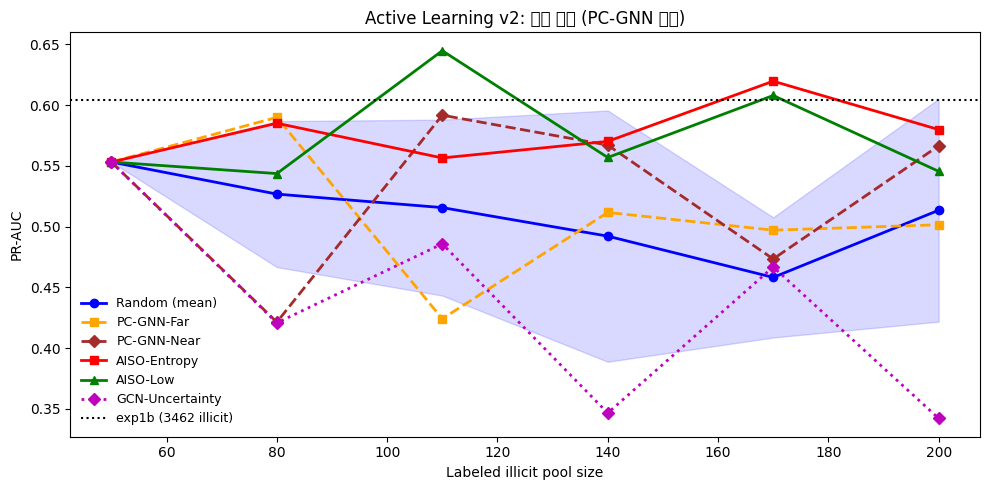

In [6]:
# 결과 테이블
rand_arr  = np.array(rand_curves)
rand_mean = rand_arr.mean(0)
rand_std  = rand_arr.std(0)
n_rounds  = len(rand_mean)
pool_sizes = [50 + r*30 for r in range(n_rounds)]

all_curves = {
    'Random (mean)':   rand_mean,
    'PC-GNN-Far':      np.array(curve_pcg_far),
    'PC-GNN-Near':     np.array(curve_pcg_near),
    'AISO-Entropy':    np.array(curve_ent),
    'AISO-Low':        np.array(curve_low),
    'GCN-Uncertainty': np.array(curve_gcn),
}

print(f"{'Pool':>6}  {'Random±std':>16}  {'PCG-Far':>8}  {'PCG-Near':>9}  {'AISO-Ent':>9}  {'AISO-Low':>9}  {'GCN-Unc':>8}")
print("-"*85)
for r in range(n_rounds):
    rand_s = f"{rand_mean[r]:.4f}±{rand_std[r]:.4f}"
    print(f"{pool_sizes[r]:>6}  {rand_s:>16}  "
          f"{curve_pcg_far[r]:>8.4f}  {curve_pcg_near[r]:>9.4f}  "
          f"{curve_ent[r]:>9.4f}  {curve_low[r]:>9.4f}  {curve_gcn[r]:>8.4f}")
print()
print(f"{'Mean':>6}  {rand_mean.mean():.4f}±{rand_std.mean():.4f}        "
      f"  {np.mean(curve_pcg_far):>8.4f}  {np.mean(curve_pcg_near):>9.4f}"
      f"  {np.mean(curve_ent):>9.4f}  {np.mean(curve_low):>9.4f}  {np.mean(curve_gcn):>8.4f}")
print(f"\nexp1b baseline (full 3462 illicit): 0.6041")

# 시각화
colors = {'Random (mean)'  : ('b','o','-'),
          'PC-GNN-Far'     : ('orange','s','--'),
          'PC-GNN-Near'    : ('brown','D','--'),
          'AISO-Entropy'   : ('r','s','-'),
          'AISO-Low'       : ('g','^','-'),
          'GCN-Uncertainty': ('m','D',':'),}

fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(pool_sizes, rand_mean-rand_std, rand_mean+rand_std, alpha=0.15, color='b')
for name, curve in all_curves.items():
    c, m, ls = colors[name]
    ax.plot(pool_sizes, curve, color=c, marker=m, linestyle=ls, label=name, linewidth=2)
ax.axhline(0.6041, color='k', linestyle=':', linewidth=1.5, label='exp1b (3462 illicit)')
ax.set_xlabel("Labeled illicit pool size"); ax.set_ylabel("PR-AUC")
ax.set_title("Active Learning v2: 전략 비교 (PC-GNN 포함)")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()


## Exp 4c v2 — Anomaly Detection

**변경**: OCSVM + Autoencoder 베이스라인 추가, AISO 5시드 평균

| 방법 | 타입 | 피처 | 레이블 |
|------|------|------|--------|
| AISO (5 seeds) | 스웜 표현 | Dom-12 | 불필요 |
| Isolation Forest | 앙상블 | Dom-12 | 불필요 |
| OCSVM (RBF) | 커널 원-클래스 | Dom-12 | 불필요 |
| Autoencoder | 재구성 오차 | Dom-12 | 불필요 |
| LOF | 밀도 기반 | Dom-12 | 불필요 |


In [7]:
# licit 학습 데이터
rng_licit  = np.random.RandomState(SEED)
licit_samp = rng_licit.choice(train_licit_idx, 3000, replace=False)
X_licit    = domain_norm_12[licit_samp]
X_test_12  = domain_norm_12[test_idx]
y_te       = y_all[test_idx]

print(f"licit 학습: {len(licit_samp)}개")
print(f"테스트: {len(y_te)}개  illicit={y_te.sum()}  (비율={y_te.mean():.4f})")


licit 학습: 3000개
테스트: 16670개  illicit=1083  (비율=0.0650)


In [8]:
# ── AISO: 5시드 평균 ─────────────────────────────────────────────────────────
AISO_SEEDS = [42, 0, 7, 77, 123]
aiso_scores = []

for s in AISO_SEEDS:
    W_l, W_ag_l, M_l = learn_w(X_licit, SEED=s)
    reg_l = Ridge(alpha=0.1).fit(X_licit, W_l)
    W_te  = reg_l.predict(X_test_12)
    W_te  = np.maximum(W_te,1e-8); W_te /= W_te.sum(1,keepdims=True)
    km_l  = KMeans(8, random_state=s, n_init=10).fit(W_ag_l)
    proto = km_l.cluster_centers_; proto /= proto.sum(1,keepdims=True)
    sc    = np.array([-np.max(proto @ M_l @ W_te[j]) for j in range(len(test_idx))])
    sc    = (sc-sc.min())/(sc.max()-sc.min()+1e-8)
    aiso_scores.append(sc)
    pr  = average_precision_score(y_te, sc)
    auc = roc_auc_score(y_te, sc)
    print(f"  AISO seed={s:3d}  PR-AUC={pr:.4f}  ROC-AUC={auc:.4f}")

aiso_sc_mean = np.mean(aiso_scores, axis=0)
pr_aiso  = average_precision_score(y_te, aiso_sc_mean)
auc_aiso = roc_auc_score(y_te, aiso_sc_mean)
print(f"  AISO mean      PR-AUC={pr_aiso:.4f}  ROC-AUC={auc_aiso:.4f}")


  AISO seed= 42  PR-AUC=0.2563  ROC-AUC=0.7434
  AISO seed=  0  PR-AUC=0.0870  ROC-AUC=0.5758
  AISO seed=  7  PR-AUC=0.0481  ROC-AUC=0.3775
  AISO seed= 77  PR-AUC=0.0462  ROC-AUC=0.3502
  AISO seed=123  PR-AUC=0.0398  ROC-AUC=0.2513
  AISO mean      PR-AUC=0.1242  ROC-AUC=0.5647


In [9]:
# ── Isolation Forest ─────────────────────────────────────────────────────────
iso = IsolationForest(random_state=SEED, contamination=0.1, n_estimators=200)
iso.fit(X_licit)
iso_sc = -iso.score_samples(X_test_12)

# ── OCSVM ────────────────────────────────────────────────────────────────────
print("OCSVM 학습 중...")
ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
ocsvm.fit(X_licit)
ocsvm_sc = -ocsvm.score_samples(X_test_12)

# ── LOF ───────────────────────────────────────────────────────────────────────
lof = LocalOutlierFactor(novelty=True, contamination=0.1, n_neighbors=20)
lof.fit(X_licit)
lof_sc = -lof.score_samples(X_test_12)

# ── Autoencoder ──────────────────────────────────────────────────────────────
print("Autoencoder 학습 중...")

class AE(nn.Module):
    def __init__(self, d=12, h=8, z=4):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Linear(h,z))
        self.dec = nn.Sequential(nn.Linear(z,h), nn.ReLU(), nn.Linear(h,d))
    def forward(self, x): return self.dec(self.enc(x))

torch.manual_seed(SEED)
ae  = AE().to(DEVICE)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
Xl  = torch.tensor(X_licit, dtype=torch.float).to(DEVICE)
Xt  = torch.tensor(X_test_12, dtype=torch.float).to(DEVICE)

for ep in range(300):
    ae.train(); opt.zero_grad()
    loss = F.mse_loss(ae(Xl), Xl)
    loss.backward(); opt.step()

ae.eval()
with torch.no_grad():
    recon = ae(Xt).cpu().numpy()
ae_sc = np.mean((X_test_12 - recon)**2, axis=1)

print("완료")


OCSVM 학습 중...
Autoencoder 학습 중...
완료


In [10]:
# ── 결과 비교 테이블 ─────────────────────────────────────────────────────────
methods = [
    ('AISO (5-seed mean)', aiso_sc_mean),
    ('Isolation Forest',   iso_sc),
    ('OCSVM (RBF)',        ocsvm_sc),
    ('Autoencoder',        ae_sc),
    ('LOF',                lof_sc),
]

print(f"테스트: {len(y_te)}개  illicit={y_te.sum()}  (6.50%)")
print()
print(f"  {'방법':<22} {'PR-AUC':>8} {'ROC-AUC':>9}")
print("-"*44)
results_4c = {}
for nm, sc in methods:
    pr  = average_precision_score(y_te, sc)
    auc = roc_auc_score(y_te, sc)
    results_4c[nm] = (pr, auc)
    flag = " ★" if pr == max(average_precision_score(y_te, s) for _,s in methods) else ""
    print(f"  {nm:<22} {pr:>8.4f} {auc:>9.4f}{flag}")
print(f"  {'Random baseline':<22} {y_te.mean():>8.4f}  (=illicit 비율)")


테스트: 16670개  illicit=1083  (6.50%)

  방법                       PR-AUC   ROC-AUC
--------------------------------------------
  AISO (5-seed mean)       0.1242    0.5647
  Isolation Forest         0.2169    0.7522
  OCSVM (RBF)              0.4019    0.6225 ★
  Autoencoder              0.3775    0.5933
  LOF                      0.0406    0.2585
  Random baseline          0.0650  (=illicit 비율)


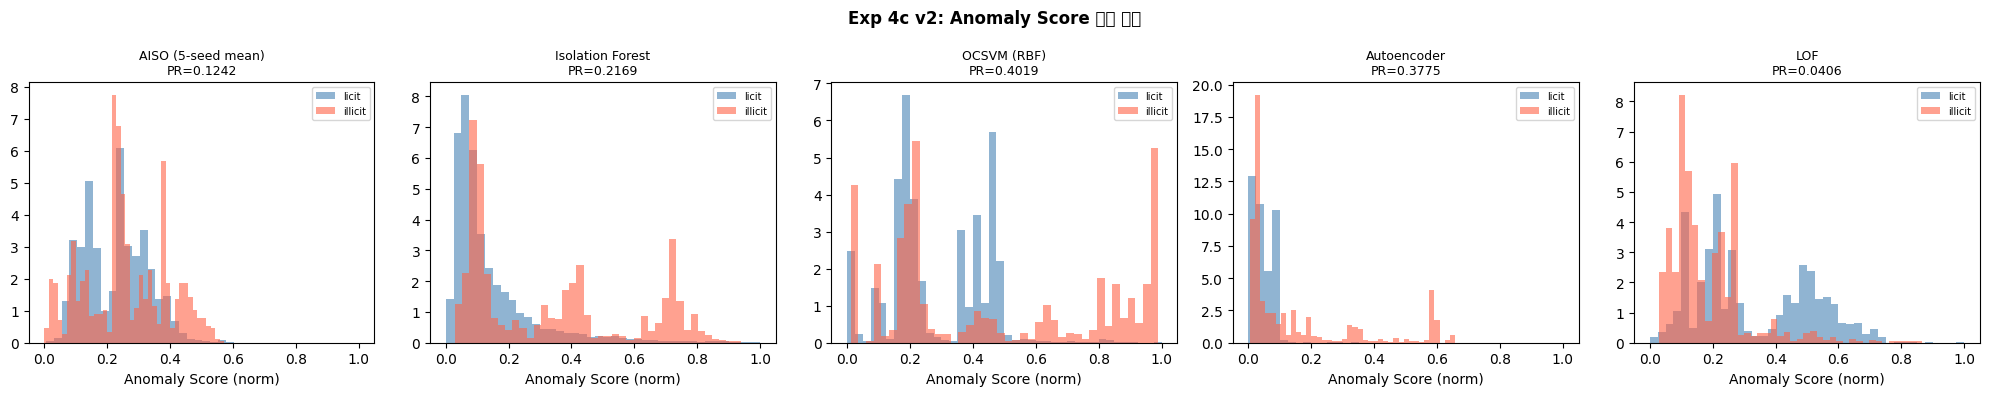

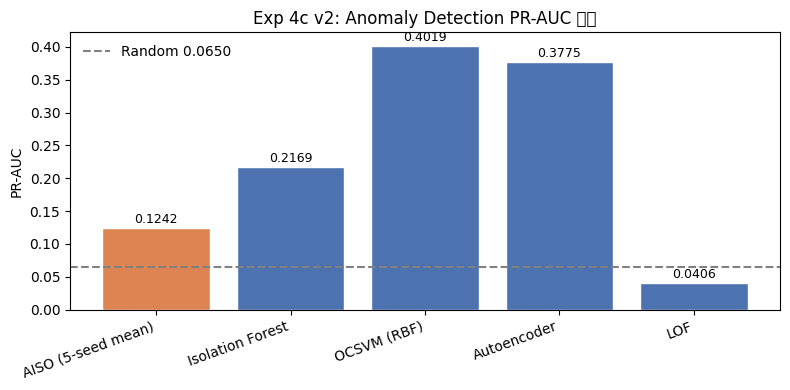

: 

In [ ]:
# 시각화
fig, axes = plt.subplots(1, len(methods), figsize=(4*len(methods), 4))
for ax, (nm, sc) in zip(axes, methods):
    sc_norm = (sc-sc.min())/(sc.max()-sc.min()+1e-8)
    ax.hist(sc_norm[y_te==0], bins=40, alpha=0.6, label='licit',
            color='steelblue', density=True)
    ax.hist(sc_norm[y_te==1], bins=40, alpha=0.6, label='illicit',
            color='tomato', density=True)
    pr = average_precision_score(y_te, sc)
    ax.set_title(f'{nm}\nPR={pr:.4f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('Anomaly Score (norm)')
plt.suptitle('Exp 4c v2: Anomaly Score 분포 비교', fontweight='bold')
plt.tight_layout(); plt.show()

# PR-AUC 바 차트
names = [nm for nm,_ in methods]
prs   = [results_4c[nm][0] for nm in names]
cols  = ['#DD8452' if nm.startswith('AISO') else '#4C72B0' for nm in names]

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(names, prs, color=cols, edgecolor='white')
ax.axhline(y_te.mean(), color='gray', linestyle='--', label=f'Random {y_te.mean():.4f}')
for bar, v in zip(bars, prs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('PR-AUC'); ax.set_title('Exp 4c v2: Anomaly Detection PR-AUC 비교')
ax.legend(frameon=False); plt.tight_layout(); plt.show()
